# Project 3 — AI Recommendation Logic
### DecodeLabs Industrial Training Kit | Batch 2026

**Capstone: Tech Stack Recommender**

**Goal:** Build a simple content-based recommendation system that maps a
user's raw skills and career interests to the most relevant job roles —
without needing any historical user-behavior data (no "cold start" problem
for new items).

**Pipeline (IPO Framework):**
- **Input:** User skills (minimum 3), `raw_skills.csv` (job roles + their tagged skills)
- **Process:** TF-IDF vector mapping + Cosine Similarity scoring
- **Output:** Ranked Top-N job role recommendations

**Key skills demonstrated:** logic building, pattern matching, recommendation concepts.


## 1. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
pd.set_option('display.max_colwidth', None)


## 2. Ingestion — The `raw_skills.csv` Dataset

Every recommendation engine needs an item catalogue. Here, our "items" are
**job roles**, each described by a set of associated skills/tools (its
"content"). This cell generates `raw_skills.csv` so the notebook is fully
self-contained and runnable in Colab with zero uploads — but in a real
project you would load this from a file you maintain (e.g. scraped from job
postings or curated manually).


In [2]:
job_roles_data = {
    "job_role": [
        "Data Scientist",
        "Machine Learning Engineer",
        "DevOps Engineer",
        "Backend Developer",
        "Frontend Developer",
        "Cloud Architect",
        "Data Analyst",
        "Mobile App Developer",
        "Cybersecurity Analyst",
        "AI Research Engineer",
        "Database Administrator",
        "Full Stack Developer",
    ],
    "skills": [
        "Python SQL Machine Learning Data Analysis Statistics Pandas Visualization",
        "Python Machine Learning Deep Learning TensorFlow PyTorch Data Structures Algorithms",
        "AWS Docker Kubernetes CI/CD Automation Linux Cloud Networking",
        "Java Python SQL APIs Data Structures Algorithms Microservices",
        "JavaScript React CSS HTML Web Design UI/UX Frontend Development",
        "AWS Cloud Networking Security Automation Kubernetes Docker Terraform",
        "SQL Excel Python Data Analysis Visualization Statistics Reporting",
        "Java Kotlin Swift Mobile Development UI/UX APIs",
        "Networking Security Linux Python Cryptography Risk Analysis",
        "Python Machine Learning Deep Learning Research Mathematics Algorithms",
        "SQL Database Design Linux Backup Security Data Structures",
        "JavaScript Python SQL React APIs Web Design Backend Development",
    ],
}

df_jobs = pd.DataFrame(job_roles_data)
df_jobs.to_csv("raw_skills.csv", index=False)

print(f"Dataset saved: raw_skills.csv ({df_jobs.shape[0]} job roles)")
df_jobs


Dataset saved: raw_skills.csv (12 job roles)


,job_role,skills
0,Data Scientist,Python SQL Machine Learning Data Analysis Statistics Pandas Visualization
1,Machine Learning Engineer,Python Machine Learning Deep Learning TensorFlow PyTorch Data Structures Algorithms
2,DevOps Engineer,AWS Docker Kubernetes CI/CD Automation Linux Cloud Networking
3,Backend Developer,Java Python SQL APIs Data Structures Algorithms Microservices
4,Frontend Developer,JavaScript React CSS HTML Web Design UI/UX Frontend Development
5,Cloud Architect,AWS Cloud Networking Security Automation Kubernetes Docker Terraform
6,Data Analyst,SQL Excel Python Data Analysis Visualization Statistics Reporting
7,Mobile App Developer,Java Kotlin Swift Mobile Development UI/UX APIs
8,Cybersecurity Analyst,Networking Security Linux Python Cryptography Risk Analysis
9,AI Research Engineer,Python Machine Learning Deep Learning Research Mathematics Algorithms


In [3]:
# In a real workflow, you'd simply load an existing file like this:
df_jobs = pd.read_csv("raw_skills.csv")
df_jobs.head()


,job_role,skills
0,Data Scientist,Python SQL Machine Learning Data Analysis Statistics Pandas Visualization
1,Machine Learning Engineer,Python Machine Learning Deep Learning TensorFlow PyTorch Data Structures Algorithms
2,DevOps Engineer,AWS Docker Kubernetes CI/CD Automation Linux Cloud Networking
3,Backend Developer,Java Python SQL APIs Data Structures Algorithms Microservices
4,Frontend Developer,JavaScript React CSS HTML Web Design UI/UX Frontend Development


## 3. Bridging the Language Barrier — Vector Mapping with TF-IDF

Machines don't understand words like "Python" or "Cloud" — they understand
numbers. We use **TF-IDF (Term Frequency–Inverse Document Frequency)**
instead of simple binary (1/0) vectors, because TF-IDF:

- Rewards specific, descriptive skills (e.g. "Kubernetes", "TensorFlow")
- Penalizes generic, overly common skills (e.g. "Python" if it appears in
  almost every role)

Crucially, the **user's skill input and the item skills must share the
exact same vocabulary** — the same `TfidfVectorizer` is used for both, so
"Web Design" and "Frontend Development" are treated as distinct terms
unless they match exactly.


In [4]:
vectorizer = TfidfVectorizer()
job_vectors = vectorizer.fit_transform(df_jobs["skills"])

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Job vector matrix shape:", job_vectors.shape)

# Peek at the TF-IDF matrix as a readable table
tfidf_df = pd.DataFrame(
    job_vectors.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_jobs["job_role"]
)
tfidf_df.round(2).iloc[:, :10]  # showing first 10 vocabulary columns


Vocabulary size: 50
Job vector matrix shape: (12, 50)


,algorithms,analysis,apis,automation,aws,backend,backup,cd,ci,cloud
job_role,,,,,,,,,,
Data Scientist,0.00,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Machine Learning Engineer,0.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DevOps Engineer,0.00,0.00,0.00,0.33,0.33,0.00,0.00,0.38,0.38,0.33
Backend Developer,0.36,0.00,0.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Frontend Developer,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Cloud Architect,0.00,0.00,0.00,0.36,0.36,0.00,0.00,0.00,0.00,0.36
Data Analyst,0.00,0.34,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Mobile App Developer,0.00,0.00,0.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Cybersecurity Analyst,0.00,0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 4. Entering the Similarity Engine — Cosine Similarity

Euclidean distance is sensitive to the *magnitude* of vectors (a job role
with many listed skills would look "far" from a user profile with just 3
skills, even if those 3 skills perfectly match). **Cosine similarity**
instead measures the **angle** between two vectors, making it insensitive
to length — it captures *orientation* (i.e. how aligned the skill sets are),
which is exactly what we want here.

- Score close to **1** → strong alignment (great match)
- Score close to **0** → little to no overlap


## 5. The 4-Step Ranking Pipeline

1. **Ingestion** — capture the user's input skills (minimum 3)
2. **Scoring** — compute cosine similarity between the user vector and every job role vector
3. **Sorting** — order job roles by descending similarity score
4. **Filtering** — truncate to the Top-N most relevant roles


In [5]:
def recommend_tech_stack(user_skills, top_n=3):
    """
    Recommend job roles based on a list of user skills using
    TF-IDF + Cosine Similarity content-based filtering.

    Parameters
    ----------
    user_skills : list[str]
        The user's skills/interests (minimum 3 recommended for data density).
    top_n : int
        Number of top recommendations to return.

    Returns
    -------
    pandas.DataFrame with columns: job_role, match_score (%)
    """
    if len(user_skills) < 3:
        print("⚠️  Warning: fewer than 3 skills provided. "
              "Recommendations may be less accurate (data sparsity).")

    # Step 1: Ingestion — build the user's profile as one skill string
    user_profile_text = " ".join(user_skills)

    # Step 2: Scoring — vectorize the user profile using the SAME
    # fitted vocabulary as the job roles, then compute cosine similarity
    user_vector = vectorizer.transform([user_profile_text])
    similarity_scores = cosine_similarity(user_vector, job_vectors).flatten()

    # Step 3: Sorting — attach scores and sort descending
    results = df_jobs.copy()
    results["match_score"] = (similarity_scores * 100).round(1)
    results = results.sort_values("match_score", ascending=False)

    # Cold-start guard: if every score is 0, the user's skills don't
    # exist anywhere in our vocabulary
    if results["match_score"].max() == 0:
        print("⚠️  No overlapping skills found in our catalogue "
              "(cold start). Falling back to trending/popular roles.")
        return results[["job_role", "skills"]].head(top_n)

    # Step 4: Filtering — return only the Top-N
    return results[["job_role", "match_score"]].head(top_n).reset_index(drop=True)


## 6. Try It — Enter Your Own Skills

Edit the `my_skills` list below with at least 3 skills or interests, then
run the cell to get your Top-3 recommended tech career paths.


In [6]:
my_skills = ["Python", "Cloud Computing", "Automation"]

recommendations = recommend_tech_stack(my_skills, top_n=3)
print(f"Input skills: {my_skills}\n")
recommendations


Input skills: ['Python', 'Cloud Computing', 'Automation']



,job_role,match_score
0,Cloud Architect,46.2
1,DevOps Engineer,42.7
2,Backend Developer,9.6


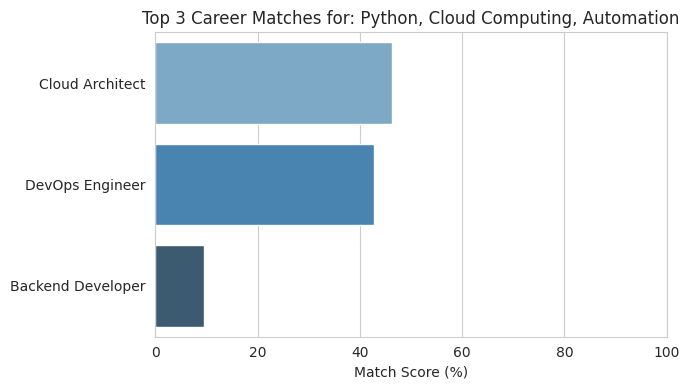

In [7]:
# Visualize the match scores
plt.figure(figsize=(7, 4))
sns.barplot(
    data=recommendations,
    x="match_score", y="job_role",
    hue="job_role", palette="Blues_d", legend=False
)
plt.xlabel("Match Score (%)")
plt.ylabel("")
plt.title(f"Top {len(recommendations)} Career Matches for: {', '.join(my_skills)}")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


### More Examples

In [8]:
examples = [
    ["JavaScript", "React", "Web Design"],
    ["Kubernetes", "AWS", "Security"],
    ["Deep Learning", "Research", "Mathematics"],
]

for skills in examples:
    print(f"\nInput skills: {skills}")
    display(recommend_tech_stack(skills, top_n=3))



Input skills: ['JavaScript', 'React', 'Web Design']


,job_role,match_score
0,Full Stack Developer,70.6
1,Frontend Developer,59.6
2,Database Administrator,15.3



Input skills: ['Kubernetes', 'AWS', 'Security']


,job_role,match_score
0,Cloud Architect,59.3
1,DevOps Engineer,39.4
2,Cybersecurity Analyst,18.8



Input skills: ['Deep Learning', 'Research', 'Mathematics']


,job_role,match_score
0,AI Research Engineer,84.1
1,Machine Learning Engineer,38.1
2,Data Scientist,13.8


## 7. Handling the Cold-Start Problem

Because this is **content-based filtering** (not collaborative filtering),
a brand-new job role can be recommended immediately — as soon as it has
skill tags, it's usable. This is a major advantage over collaborative
filtering, which needs historical interaction data before a new item can
ever be recommended.

The remaining risk is a **user cold start**: a user whose input skills don't
overlap with *any* skill in our vocabulary produces an all-zero similarity
vector. The `recommend_tech_stack()` function above detects this case and
falls back gracefully instead of returning a meaningless empty ranking. In
production, you'd typically also use:

- **Onboarding surveys** to force an initial skill selection
- **Trending fallbacks** (most in-demand roles) until enough data exists
- **Metadata inference** from demographic or cross-domain signals


In [9]:
# Cold-start example: skills with no overlap in our vocabulary
cold_start_skills = ["Photography", "Cooking", "Gardening"]
recommend_tech_stack(cold_start_skills, top_n=3)


⚠️  No overlapping skills found in our catalogue (cold start). Falling back to trending/popular roles.


,job_role,skills
0,Data Scientist,Python SQL Machine Learning Data Analysis Statistics Pandas Visualization
1,Machine Learning Engineer,Python Machine Learning Deep Learning TensorFlow PyTorch Data Structures Algorithms
2,DevOps Engineer,AWS Docker Kubernetes CI/CD Automation Linux Cloud Networking


## 8. Conclusion

This notebook implemented a complete **content-based recommendation
pipeline**:

1. Built a small job-roles catalogue (`raw_skills.csv`) as the item dataset.
2. Mapped user skills and job-role skills into the same **TF-IDF vector
   space**, so specific/rare skills carry more weight than generic ones.
3. Scored every job role against the user's profile using **Cosine
   Similarity**, which measures alignment regardless of vector magnitude.
4. Sorted and filtered results into a clean **Top-N recommendation list**.
5. Handled the **cold-start problem** gracefully with a fallback path.

**Next steps:** try expanding `raw_skills.csv` with more job roles and more
granular skill tags, or experiment with weighting certain skills manually
to see how the rankings shift. This same skeleton — vectorize → score →
sort → filter — is the foundation behind real-world recommenders like
Netflix's "Because you watched..." or Amazon's "Customers also bought."

*Project 3 — DecodeLabs Industrial Training Kit, Batch 2026*
